# On-Device Keyword Spotting — MFCC Training Pipeline

This notebook implements the full training pipeline for keyword spotting using MFCC features.
The trained model weights are exported as C arrays for deployment on Arduino.

**Target classes:** `clap`, `tap`, `snap`, `silence`

**Pipeline:**
1. Record / load audio dataset
2. Extract MFCC features (matching Arduino CMSIS pipeline)
3. Train a lightweight 1D-CNN classifier
4. Evaluate with accuracy + confusion matrix
5. Export weights as C headers

## 1. Install & Import

In [3]:
!pip install -q librosa soundfile tensorflow numpy matplotlib seaborn scipy ffmpeg-python
print('Packages installed')

Packages installed


In [4]:
import os, io, zipfile, struct, json
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from scipy.signal import get_window
from scipy.fftpack import dct
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import Audio, display, HTML
from google.colab.output import eval_js
from base64 import b64decode
import ffmpeg
from scipy.io.wavfile import read as wav_read

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load Dataset & Extract MFCC Features

In [21]:
import numpy as np
import os

CLASSES = ["clap", "tap", "snap", "whistle"]
SAMPLE_LENGTH = 2000

def load_dataset(dataset_dir='/content/dataset/', classes=CLASSES):
    X, y = [], []

    for label_idx, cls in enumerate(classes):

        file_path = os.path.join(dataset_dir, cls + ".txt")

        print("Loading:", file_path)

        if not os.path.exists(file_path):
            print("Missing file:", file_path)
            continue

        data = np.loadtxt(file_path)

        print(cls, "raw samples:", len(data))

        # split into chunks of 2000
        num_samples = len(data) // SAMPLE_LENGTH

        for i in range(num_samples):
            start = i * SAMPLE_LENGTH
            end = start + SAMPLE_LENGTH

            sample = data[start:end]

            if len(sample) == SAMPLE_LENGTH:
                X.append(sample)
                y.append(label_idx)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


X, y = load_dataset()

print("X:", X.shape)
print("y:", y.shape)
print("Class distribution:", np.bincount(y))

Loading: /content/dataset/clap.txt
clap raw samples: 40000
Loading: /content/dataset/tap.txt
tap raw samples: 40000
Loading: /content/dataset/snap.txt
snap raw samples: 40000
Loading: /content/dataset/whistle.txt
whistle raw samples: 40000
X: (80, 2000)
y: (80,)
Class distribution: [20 20 20 20]


## 7. Visualise MFCC Features

In [32]:
import librosa
import numpy as np

SAMPLE_RATE = 16000
N_MFCC = 13

def extract_mfcc(signal):
    signal = signal.astype(np.float32)

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=SAMPLE_RATE,
        n_mfcc=N_MFCC,
        n_fft=512,
        hop_length=256
    )

    return mfcc.T   # IMPORTANT: (frames, mfcc)

In [38]:
X = np.array([extract_mfcc(x) for x in X])
print(X.shape)

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=1
  warnings.warn(


(80, 1, 13, 13, 13, 13, 13, 1)


In [35]:
X_fixed = []

for x in X:
    mfcc = extract_mfcc(x)
    X_fixed.append(mfcc)

X_fixed = np.array(X_fixed, dtype=np.float32)

print("Fixed shape:", X_fixed.shape)
print("One sample:", X_fixed[0].shape)

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=1
  warnings.warn(


Fixed shape: (80, 1, 13, 13, 13, 1)
One sample: (1, 13, 13, 13, 1)


In [31]:
print(X.shape)
print(X[0][:10])

(80, 1, 13, 8)
[[[ 4.97704559e+02  4.69324249e+02  4.58685120e+02  4.55023560e+02
    4.48398315e+02  4.48712860e+02  4.46329742e+02  4.42967957e+02]
  [ 4.96459723e+00  9.46510887e+00  9.58853722e+00  1.16133156e+01
    1.00168705e+01  1.27902775e+01  1.42812176e+01  1.55130615e+01]
  [-6.51486874e+00 -7.24046326e+00 -5.81169796e+00 -8.06265354e+00
   -7.63383961e+00 -8.29398918e+00 -7.85317039e+00 -8.92284489e+00]
  [-6.76851749e-01  2.70333481e+00 -2.73120463e-01 -4.23229218e-01
    2.48545265e+00  3.23482215e-01  2.32734179e+00  1.60087144e+00]
  [ 9.71473038e-01  3.24360657e+00  3.76915455e+00  6.68355107e-01
    2.76053214e+00  1.73506904e+00  2.23188996e+00  4.74933386e-01]
  [-1.03702879e+00 -1.99710786e+00 -1.52839851e+00 -2.07308650e-01
    3.93180609e-01  6.76974058e-01 -7.04733878e-02 -9.23049271e-01]
  [-1.12079948e-01 -1.10898626e+00 -1.32165480e+00 -3.43852311e-01
   -5.21558166e-01 -1.88067806e+00 -8.48327458e-01  8.22085887e-02]
  [-2.55285352e-02  1.23686326e+00  1.25

In [29]:
X_mfcc = np.array([extract_mfcc(x) for x in X], dtype=np.float32)

print("MFCC dataset shape:", X_mfcc.shape)

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=8
  warnings.warn(


MFCC dataset shape: (80, 1, 13, 13, 1)


In [30]:
print(X_mfcc[0].shape)

(1, 13, 13, 1)


## 8. Normalise & Split Dataset

In [43]:
# Normalise across training set — save mean/std for Arduino
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Normalisation mean shape: {mean.shape}')

# Save normalisation parameters
np.save('norm_mean.npy', mean)
np.save('norm_std.npy',  std)
print('Normalisation parameters saved.')

Train: (12, 97, 13), Val: (4, 97, 13), Test: (4, 97, 13)
Normalisation mean shape: (1, 1, 13)
Normalisation parameters saved.


## 9. Build Lightweight CNN Model

In [44]:
# Add channel dim for Conv1D
X_tr = X_train[..., np.newaxis]   # (N, frames, n_mfcc, 1)
X_v  = X_val[...,   np.newaxis]
X_te = X_test[...,  np.newaxis]

NUM_CLASSES = len(CLASSES)
input_shape = X_tr.shape[1:]   # (frames, n_mfcc, 1)

def build_model(input_shape, num_classes):
    inp = keras.Input(shape=input_shape)
    # Conv block 1
    x = layers.Conv2D(16, (3,3), activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.2)(x)
    # Conv block 2
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.2)(x)
    # Dense head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inp, out)

model = build_model(input_shape, NUM_CLASSES)
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 97, 13, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 97, 13, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 97, 13, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 48, 6, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 48, 6, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 6, 32)      │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 6, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 3, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 3, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,364 (28.77 KB)

 Trainable params: 7,268 (28.39 KB)

 Non-trainable params: 96 (384.00 B)

## 10. Train

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.2500 - loss: 1.6018 - val_accuracy: 0.2500 - val_loss: 1.3974 - learning_rate: 0.0010
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.3333 - loss: 1.4527 - val_accuracy: 0.2500 - val_loss: 1.3949 - learning_rate: 0.0010
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.2500 - loss: 1.4993 - val_accuracy: 0.2500 - val_loss: 1.3930 - learning_rate: 0.0010
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.1667 - loss: 1.5133 - val_accuracy: 0.2500 - val_loss: 1.3914 - learning_rate: 0.0010
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.4167 - loss: 1.3128 - val_accuracy: 0.2500 - val_loss: 1.3887 - learning_rate: 0.0010
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.2500 - loss: 1.2428 - val_accuracy: 0.2500 - val_loss: 1.3860 - learning_rate: 0.0010
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.2500 - loss: 1.4277 - val_accuracy: 

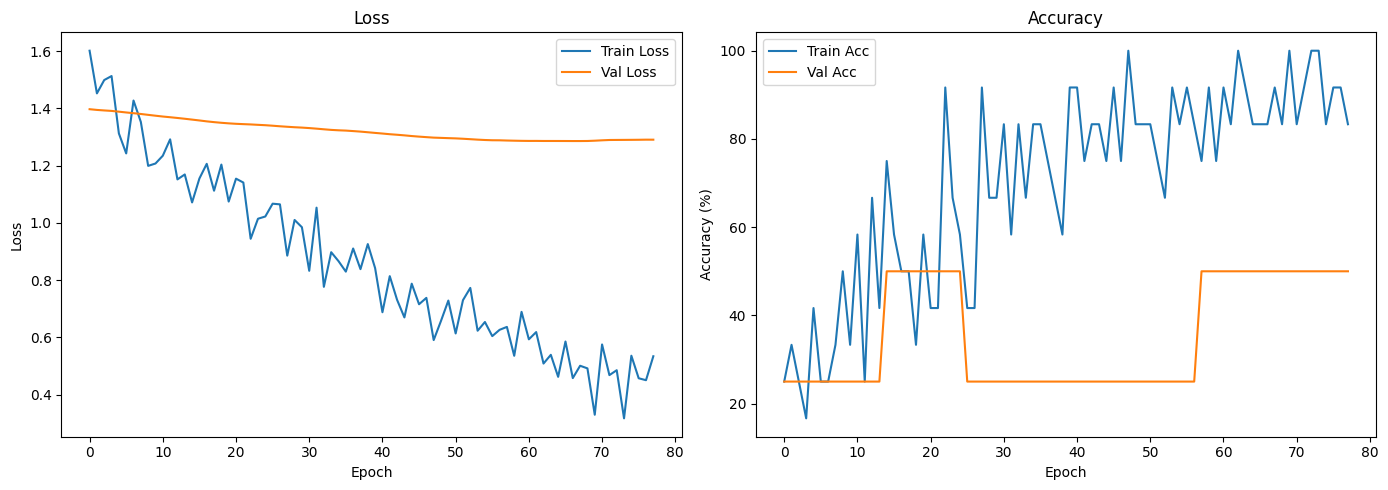

In [45]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, verbose=1, min_lr=1e-5)
]

history = model.fit(
    X_tr, y_train,
    validation_data=(X_v, y_val),
    epochs=100,
    batch_size=16,
    callbacks=callbacks
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.set_title('Loss')
ax2.plot(np.array(history.history['accuracy'])*100,     label='Train Acc')
ax2.plot(np.array(history.history['val_accuracy'])*100, label='Val Acc')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.legend(); ax2.set_title('Accuracy')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 11. Evaluate — Accuracy & Confusion Matrix

Test accuracy: 50.00%  |  Test loss: 1.2772
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step

Classification Report:
              precision    recall  f1-score   support

        clap       1.00      1.00      1.00         1
         tap       0.00      0.00      0.00         1
        snap       0.00      0.00      0.00         1
     silence       0.33      1.00      0.50         1

    accuracy                           0.50         4
   macro avg       0.33      0.50      0.38         4
weighted avg       0.33      0.50      0.38         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


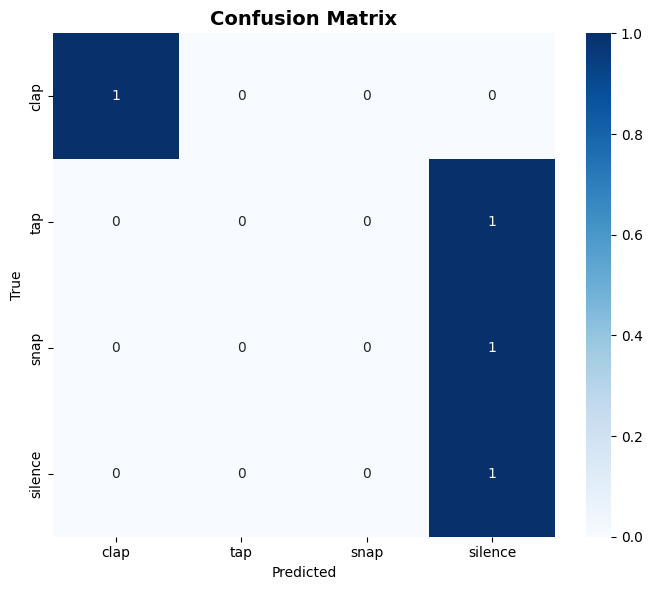

In [46]:
loss, acc = model.evaluate(X_te, y_test, verbose=0)
print(f'Test accuracy: {acc*100:.2f}%  |  Test loss: {loss:.4f}')

y_pred = np.argmax(model.predict(X_te), axis=1)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 12. Export Weights as C Header Files for Arduino

In [ ]:
def float_array_to_c(arr, name, dtype='float'):
    """Convert a numpy array to a C array literal."""
    flat = arr.flatten().astype(np.float32)
    vals = ', '.join(f'{v:.8f}f' for v in flat)
    shape_comment = '// shape: ' + ' x '.join(str(d) for d in arr.shape)
    return (f'{shape_comment}\n'
            f'static const {dtype} {name}[{len(flat)}] = {{\n  {vals}\n}};\n')


def export_model_weights(model, out_dir='arduino_weights'):
    os.makedirs(out_dir, exist_ok=True)
    header_lines = [
        '// Auto-generated by KWS_MFCC_Training.ipynb',
        '// DO NOT EDIT MANUALLY',
        '#pragma once',
        '#include <stdint.h>',
        '',
        f'#define KWS_NUM_CLASSES  {len(CLASSES)}',
        f'#define KWS_N_MFCC       {N_MFCC}',
        f'#define KWS_N_FRAMES     {N_FRAMES}',
        '',
        f'static const char* KWS_CLASS_NAMES[{len(CLASSES)}] = {{',
    ]
    header_lines += [f'  "{c}",' for c in CLASSES]
    header_lines += ['};', '']

    # Normalisation
    header_lines.append(float_array_to_c(mean.flatten(), 'KWS_NORM_MEAN'))
    header_lines.append(float_array_to_c(std.flatten(),  'KWS_NORM_STD'))

    # Mel filter bank
    header_lines.append(float_array_to_c(MEL_FILTERBANK, 'KWS_MEL_FBANK'))

    # Layer weights
    for layer in model.layers:
        weights = layer.get_weights()
        if not weights:
            continue
        safe_name = layer.name.replace('/', '_').replace('-', '_')
        for wi, w in enumerate(weights):
            var_name = f'KWS_L_{safe_name}_W{wi}'
            header_lines.append(float_array_to_c(w, var_name))

    path = os.path.join(out_dir, 'kws_model_weights.h')
    with open(path, 'w') as f:
        f.write('\n'.join(header_lines))
    print(f'Weights exported to {path}')
    return path


weights_path = export_model_weights(model)
print(f'File size: {os.path.getsize(weights_path) / 1024:.1f} KB')

## 13. Export TFLite Model (alternative / reference)

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('kws_model.tflite', 'wb') as f:
    f.write(tflite_model)
print(f'TFLite model: {len(tflite_model)/1024:.1f} KB')

# Also save Keras model
model.save('kws_model.keras')
print('Keras model saved.')

## 14. Download all outputs

In [ ]:
from google.colab import files

outputs = [
    'arduino_weights/kws_model_weights.h',
    'kws_model.tflite',
    'mfcc_visualisation.png',
    'training_curves.png',
    'confusion_matrix.png',
    'norm_mean.npy',
    'norm_std.npy',
]
for p in outputs:
    if os.path.exists(p):
        files.download(p)
        print(f'Downloading {p}')